In [101]:
import torch
from torch import nn
from torch.utils.data import DataLoader,Subset
from torchvision import utils
from torchvision import models
from torchvision import datasets
from torchvision.transforms import transforms

from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import time
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(1)


In [102]:
model_resnet18=models.resnet18(pretrained=False)
num_features=model_resnet18.fc.in_features
num_classes=10
model_resnet18.fc=nn.Linear(num_features,num_classes)

c:\Users\maa\anaconda3\envs\pytorch-312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\maa\anaconda3\envs\pytorch-312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [103]:
path2weights="./models/resnet18_pretrained.pt"
model_resnet18.load_state_dict(torch.load(path2weights))

C:\Users\maa\AppData\Local\Temp\ipykernel_11540\240487436.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet18.load_state_dict(torch.load(path2weights))


<All keys matched successfully>

In [104]:
model_resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [105]:
if torch.cuda.is_available():
    device=torch.device("cuda:0")
    model_resnet18.to(device=device)

In [106]:
print(next(model_resnet18.parameters()).device)

cuda:0


In [107]:
def deploy_model(model,dataset,device,num_classes=10,sanity_check=False):
    model.eval()  # important for batchnorm/dropout
    model.to(device)
    y_out = []
    y_gt = []
    loader = DataLoader(
        dataset,
        batch_size=512,
        shuffle=False,
        pin_memory=True
    )
    elapsed_times=[]
    with torch.no_grad():  # no gradient tracking
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            start=time.time()
            preds = model(xb)
            elapsed=time.time()-start
            elapsed_times.append(elapsed)
            
            y_out.append(preds.cpu())
            y_gt.append(yb.cpu())

    inference_time=np.mean(elapsed_times)*1000
    print("average inference time per image on %s: %.2f ms "%(device,inference_time))

    return torch.cat(y_out).numpy(), torch.cat(y_gt).numpy()

### Load Dataset

In [108]:
# define transformation
data_transformer = transforms.Compose([transforms.ToTensor()])

path2data="./data"

# loading data
test0_ds=datasets.STL10(path2data, split='test', download=False,transform=data_transformer)
print(test0_ds.data.shape)

(8000, 3, 96, 96)


In [109]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=0)

indices=list(range(len(test0_ds)))
y_test0=[y for _,y in test0_ds]
for test_index, val_index in sss.split(indices, y_test0):
    print("test:", test_index, "val:", val_index)
    print(len(val_index),len(test_index))

test: [2096 4321 2767 ... 3206 3910 2902] val: [6332 6852 1532 ... 5766 4469 1011]
1600 6400


In [110]:
val_ds=Subset(test0_ds,val_index)
test_ds=Subset(test0_ds,test_index)

print("Val: ",len(val_ds))
print("Test: ",len(test_ds))


Val:  1600
Test:  6400


In [111]:
# They are taken from chapter3 notebook
# Need for pre-processing
mean=[0.4467106, 0.43980986, 0.40664646]
std=[0.22414584,0.22148906,0.22389975]

In [112]:
test0_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    ])   

In [113]:
test0_ds.transform=test0_transformer

In [114]:
# deploy model 
y_out,y_gt=deploy_model(model_resnet18,val_ds,device=device,sanity_check=False)
print(y_out.shape,y_gt.shape)

average inference time per image on cuda:0: 1.99 ms 
(1600, 10) (1600,)


In [115]:
# get predictions
y_pred = np.argmax(y_out,axis=1)
print(y_pred.shape,y_gt.shape)

# compute accuracy 
acc=accuracy_score(y_pred,y_gt)
print("accuracy: %.2f" %acc)

(1600,) (1600,)
accuracy: 0.72


In [116]:
y_out,y_gt=deploy_model(model_resnet18,test_ds,device=device)

y_pred = np.argmax(y_out,axis=1)
acc=accuracy_score(y_pred,y_gt)
print(acc)

average inference time per image on cuda:0: 2.22 ms 
0.718125


In [117]:
# get predictions
y_pred = np.argmax(y_out,axis=1)
print(y_pred.shape,y_gt.shape)

# compute accuracy 
acc=accuracy_score(y_pred,y_gt)
print("accuracy: %.2f" %acc)

(6400,) (6400,)
accuracy: 0.72


image indices: [5157  235 3980 5192]
torch.Size([3, 100, 394])


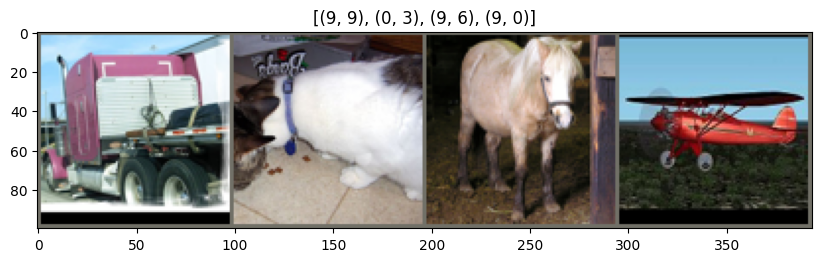

In [118]:
def imshow(inp, title=None):
    mean=[0.4467106, 0.43980986, 0.40664646]
    std=[0.22414584,0.22148906,0.22389975]
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array(mean)
    std = np.array(std)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated  

grid_size=4
rnd_inds=np.random.randint(0,len(test_ds),grid_size)
print("image indices:",rnd_inds)

x_grid_test=[test_ds[i][0] for i in rnd_inds]
y_grid_test=[(int(y_pred[i]),int(y_gt[i])) for i in rnd_inds]

x_grid_test=utils.make_grid(x_grid_test, nrow=4, padding=2)
print(x_grid_test.shape)

plt.rcParams['figure.figsize'] = (10, 5)
imshow(x_grid_test,y_grid_test)
plt.show()

In [119]:
device_cpu = torch.device("cpu")
y_out,y_gt=deploy_model(model_resnet18,val_ds,device=device_cpu,sanity_check=False)
print(y_out.shape,y_gt.shape)

average inference time per image on cpu: 749.90 ms 
(1600, 10) (1600,)
